In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('C:\\Users\\User\\Desktop\\Deep Learning\\Machine Learning Projects\\Customer Segmentation\\Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [6]:
for col in df.columns:
  temp = df[col].isnull().sum()
  if temp > 0:
    print(f"Column {col} contains {temp} null values.")

Column Description contains 1454 null values.
Column CustomerID contains 135080 null values.


In [7]:
df = df.dropna()
print("Total values in the dataset after removing the null values:", len(df))

Total values in the dataset after removing the null values: 406829


In [8]:
df.nunique()

InvoiceNo      22190
StockCode       3684
Description     3896
Quantity         436
InvoiceDate    20460
UnitPrice        620
CustomerID      4372
Country           37
dtype: int64

In [9]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df_cleaned = df.drop(columns=['Description'])

print("Features after selection:")
display(df_cleaned.head())
print(f"\nRemaining columns: {df_cleaned.columns.tolist()}")

Features after selection:


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34



Remaining columns: ['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


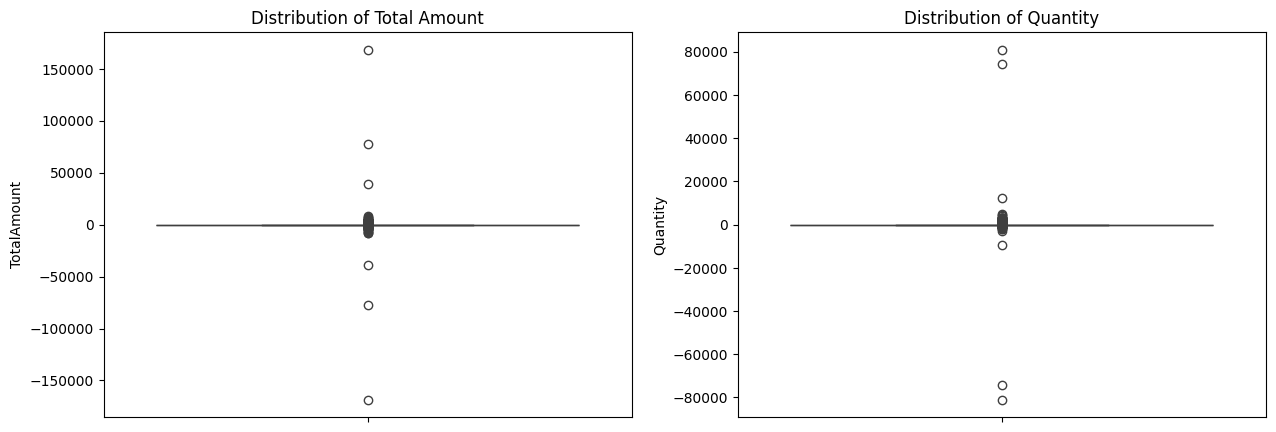

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['TotalAmount'])
plt.title('Distribution of Total Amount')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['Quantity'])
plt.title('Distribution of Quantity')

plt.show()

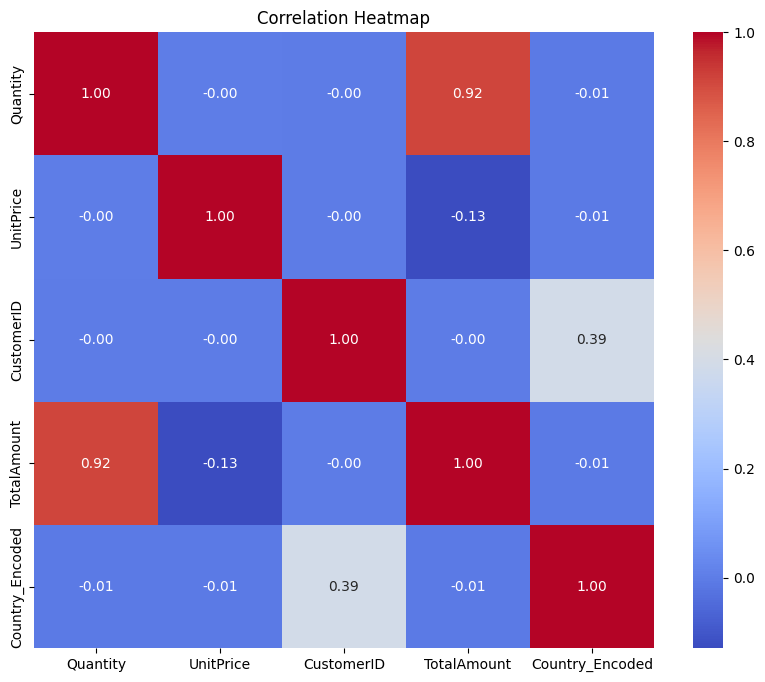

In [11]:
le = LabelEncoder()
df_cleaned['Country_Encoded'] = le.fit_transform(df_cleaned['Country'])

corr_matrix = df_cleaned[['Quantity', 'UnitPrice', 'CustomerID', 'TotalAmount', 'Country_Encoded']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

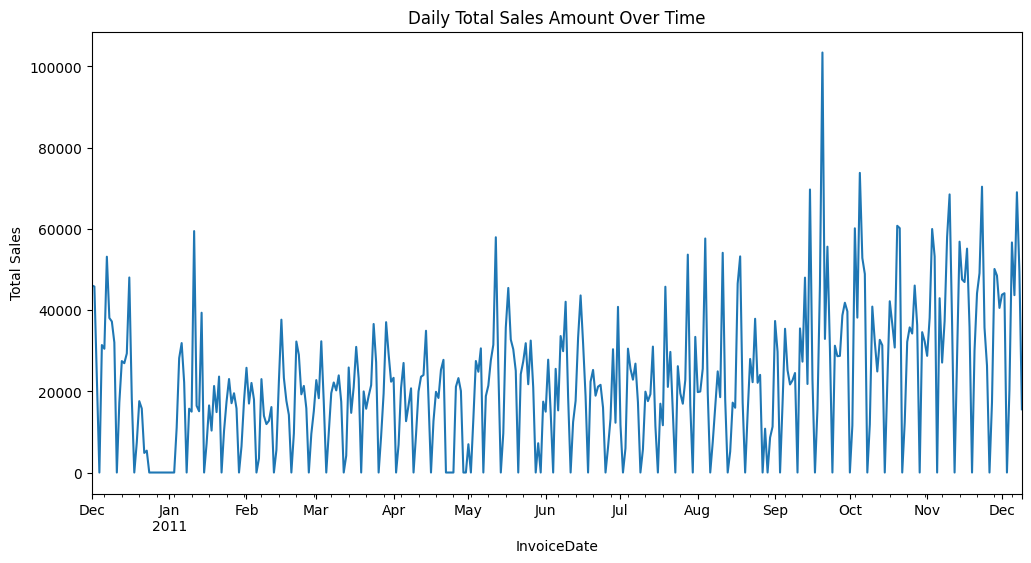

In [12]:
df_cleaned.set_index('InvoiceDate')['TotalAmount'].resample('D').sum().plot(figsize=(12,6))
plt.title('Daily Total Sales Amount Over Time')
plt.ylabel('Total Sales')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'France'),
  Text(3, 0, 'EIRE'),
  Text(4, 0, 'Spain'),
  Text(5, 0, 'Netherlands'),
  Text(6, 0, 'Belgium'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'Portugal'),
  Text(9, 0, 'Australia')])

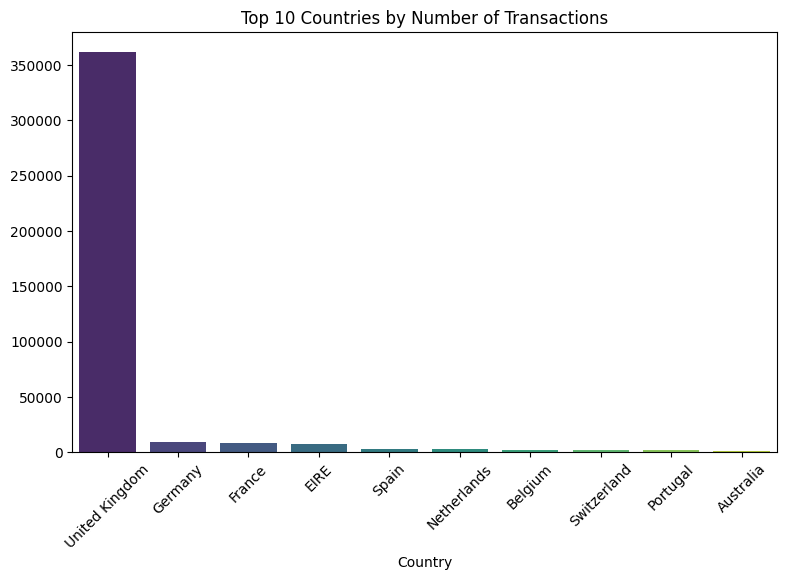

In [13]:
plt.figure(figsize=(20, 12))

plt.subplot(2, 2, 1)
top_countries = df_cleaned['Country'].value_counts().nlargest(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries by Number of Transactions')
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Distribution of Unit Price (Prices < 50)')

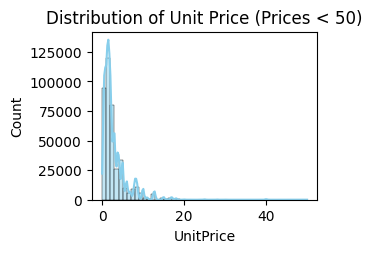

In [14]:
plt.subplot(2, 2, 2)
sns.histplot(df_cleaned[df_cleaned['UnitPrice'] < 50]['UnitPrice'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Unit Price (Prices < 50)')

Text(0.5, 1.0, 'Distribution of Quantity (0 to 50)')

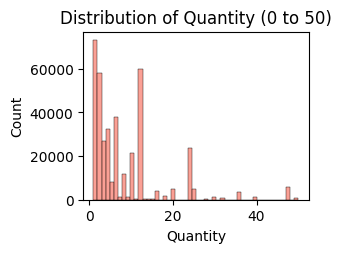

In [15]:
plt.subplot(2, 2, 3)
sns.histplot(df_cleaned[df_cleaned['Quantity'].between(0, 50)]['Quantity'], bins=50, color='salmon')
plt.title('Distribution of Quantity (0 to 50)')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Switzerland'),
  Text(7, 0, 'Spain'),
  Text(8, 0, 'Belgium'),
  Text(9, 0, 'Sweden')])

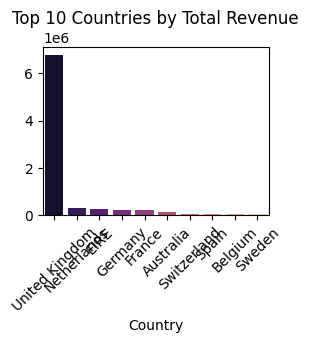

In [16]:
plt.subplot(2, 2, 4)
top_revenue_countries = df_cleaned.groupby('Country')['TotalAmount'].sum().nlargest(10)
sns.barplot(x=top_revenue_countries.index, y=top_revenue_countries.values, palette='magma')
plt.title('Top 10 Countries by Total Revenue')
plt.xticks(rotation=45)

In [17]:
scaler = StandardScaler()
numerical_cols = ['Quantity', 'UnitPrice', 'TotalAmount', 'Country_Encoded']
data_scaled = scaler.fit_transform(df_cleaned[numerical_cols])

print("Successfully scaled the numerical features.")
print("Scaled data shape:", data_scaled.shape)

Successfully scaled the numerical features.
Scaled data shape: (406829, 4)


In [18]:
df_filtered = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)].copy()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_filtered[['Quantity', 'UnitPrice', 'TotalAmount', 'Country_Encoded']])

kmeans = KMeans(init='k-means++', n_clusters=4, max_iter=500, random_state=22)
df_filtered['Segment'] = kmeans.fit_predict(data_scaled)

print("Clustering complete. Labels assigned to 'Segment' column.")

Clustering complete. Labels assigned to 'Segment' column.


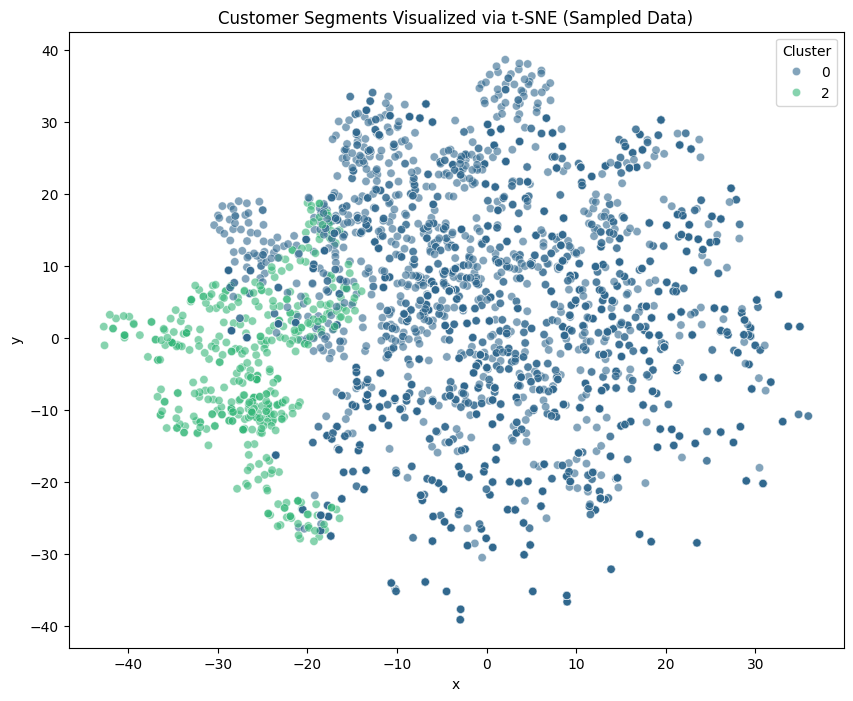

In [19]:
from sklearn.manifold import TSNE

df_sample = df_filtered.sample(5000, random_state=42)
sample_scaled = scaler.transform(df_sample[['Quantity', 'UnitPrice', 'TotalAmount', 'Country_Encoded']])

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
data_tsne = tsne.fit_transform(sample_scaled)

df_tsne_plot = pd.DataFrame({
    'x': data_tsne[:, 0],
    'y': data_tsne[:, 1],
    'Segment': df_sample['Segment'].astype(str)
})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='x', y='y', hue='Segment', data=df_tsne_plot, palette='viridis', alpha=0.6)
plt.title('Customer Segments Visualized via t-SNE (Sampled Data)')
plt.legend(title='Cluster')
plt.show()

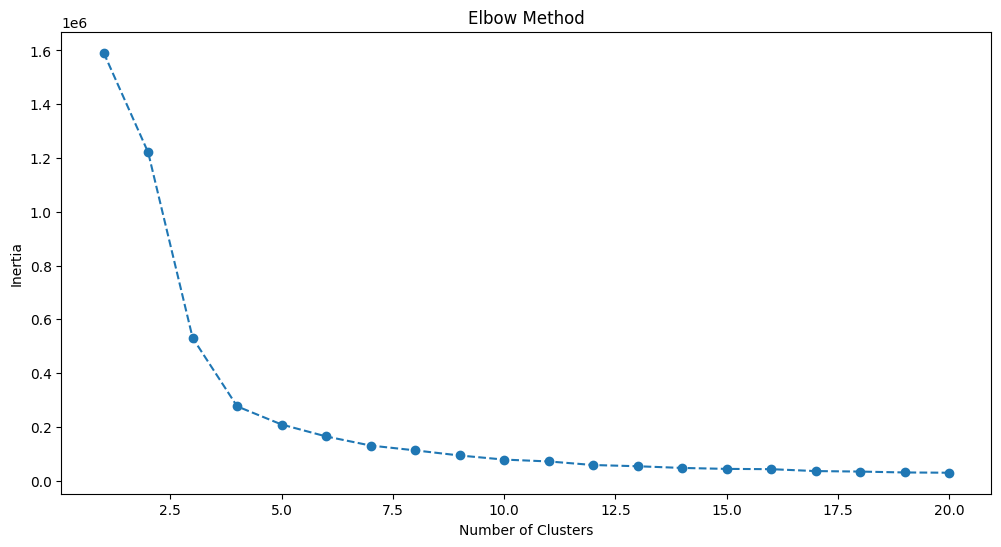

In [20]:
error = []
for n_clusters in range(1, 21):
  model = KMeans(n_clusters=n_clusters, max_iter=500, random_state=22)
  model.fit(data_scaled)
  error.append(model.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 21), error, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

### Segment Analysis
To understand the characteristics of each cluster, we calculate the mean values of our key metrics per segment.

In [21]:
cluster_analysis = df_filtered.groupby('Segment')[['Quantity', 'UnitPrice', 'TotalAmount']].mean()
cluster_counts = df_filtered['Segment'].value_counts().rename('Count')

final_summary = pd.concat([cluster_analysis, cluster_counts], axis=1)
print("Average metrics per segment:")
display(final_summary)

Average metrics per segment:


,Quantity,UnitPrice,TotalAmount,Count
Segment,,,,
0,11.704961,2.924128,19.990270,362718
1,77605.000000,1.560000,122826.600000,2
2,21.821611,3.836269,38.989346,35148
3,1.000000,2782.909375,2782.909375,16


In [22]:
import pickle

with open('customer_segmentation_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('segmented_retail_data.pkl', 'wb') as f:
    pickle.dump(df_filtered, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model, Scaler, and Data successfully saved to pickle files.")

Model, Scaler, and Data successfully saved to pickle files.
